# Primary Model: CNN

In [17]:
# imports
import io
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset, Audio
import numpy as np

## Configuration

In [18]:
# audio processing parameters
SAMPLE_RATE = 22050
CLIP_DURATION = 5          # seconds
CLIP_SAMPLES = SAMPLE_RATE * CLIP_DURATION

N_MELS = 128 # number of Mel filterbanks for the spectrogram
FFT_SIZE = 2048 # 93ms window size at 22050 Hz
HOP_LENGTH = 512 # 23ms hop size at 22050 Hz

# hyperparameters
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-3

# dataset sampling
DATASET_SAMPLE_COUNT = 1000  # set to None to use the full dataset

RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# performance settings
FEATURE_CACHE = True                    # cache computed mel+label after first access
DATALOADER_NUM_WORKERS = 2 if DEVICE == "cuda" else 0
PIN_MEMORY = DEVICE == "cuda"
PERSISTENT_WORKERS = DATALOADER_NUM_WORKERS > 0
PREFETCH_FACTOR = 2
USE_AMP = DEVICE == "cuda"

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True

## Audio Processing Utilities

Audio samples are:
- Resampled to ensure a consistent sampling rate between clips
- Segmented into non-overlapping 5-second clips when long enough
- Reduced to exactly one segment per example (the first full segment)
- Padded or trimmed to 5 seconds when needed

In [19]:
def resample_audio(waveform, original_sr):
    if original_sr != SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(original_sr, SAMPLE_RATE)
        waveform = resampler(waveform)
    return waveform

def pad_or_trim_audio(waveform):
    total_samples = waveform.shape[1]  # number of samples in the audio clip

    if total_samples < CLIP_SAMPLES:
        padding = CLIP_SAMPLES - total_samples
        waveform = F.pad(waveform, (0, padding))  # pad with zeros at the end
    elif total_samples > CLIP_SAMPLES:
        waveform = waveform[:, :CLIP_SAMPLES]

    return waveform

def segment_audio(waveform):
    # returns all full 5-second non-overlapping segments from the input waveform
    segments = []
    total_samples = waveform.shape[1]

    if total_samples < CLIP_SAMPLES:
        return segments

    for start in range(0, total_samples - CLIP_SAMPLES + 1, CLIP_SAMPLES):
        end = start + CLIP_SAMPLES
        segment = waveform[:, start:end]

        if segment.shape[1] == CLIP_SAMPLES:
            segments.append(segment)

    return segments

def select_single_segment(waveform):
    # keep one segment per example; fallback pads/trims short clips to 5 seconds
    segments = segment_audio(waveform)
    if segments:
        return segments[0]
    return pad_or_trim_audio(waveform)

Audio clips are transformed into Mel spectrograms in order to be inputted into CNN. 

- `n_fft` the window size of the fast Fourier Transform. Larger = better frequency resolution but coarser time resolution.
- `hop_length` the stride between FFT windows
- `n_mels` number of Mel filterbanks" number of freqeuency "buckets" in the output

Using the standard values set above, this results in a shape of **(1, 128, 216)**, which is passed as the CNN input. 

In [20]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=FFT_SIZE,
    hop_length=HOP_LENGTH, 
    n_mels=N_MELS
)

amplitude_to_db = torchaudio.transforms.AmplitudeToDB() # converts the Mel spectrogram to decibel (dB) scale for better visualization and model performance

def audio_to_mel(waveform):

    mel = mel_transform(waveform)

    mel_db = amplitude_to_db(mel)

    return mel_db

## Load Dataset

In [21]:
# login Hugging Face Hub
import os
from dotenv import load_dotenv

load_dotenv()  
HF_TOKEN = os.getenv("HF_TOKEN")

from huggingface_hub import login

login(token=HF_TOKEN) 

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Try primary model with smaller dataset first

In [22]:
# load dataset
# ds = load_dataset("SleepyJesse/ai_music_tiny", split="train", cache_dir="./data")
ds = load_dataset("SleepyJesse/ai_music_tiny", split="train")

# Avoid torchcodec decoding in environments where FFmpeg/TorchCodec isn't configured.
ds = ds.cast_column("audio", Audio(decode=False))

if DATASET_SAMPLE_COUNT is not None: # if a sample count is specified
    sample_count = min(DATASET_SAMPLE_COUNT, len(ds))
    ds = ds.shuffle(seed=RANDOM_SEED).select(range(sample_count)) # shuffle and select a subset 
    print(f"Using {sample_count} sampled examples from the dataset.")

ds

Using 1000 sampled examples from the dataset.


Dataset({
    features: ['audio', 'ai_generated', 'source'],
    num_rows: 1000
})

In [23]:
# Hugging Face dataset wrapper
class MusicDataset(Dataset):

    def __init__(self, hf_dataset, cache_features=FEATURE_CACHE):  # expects a Hugging Face dataset object
        self.hf_dataset = hf_dataset
        self.cache_features = cache_features
        self._feature_cache = {}
# ----------------------------------------------------------------------------------------------------------------------------------
    def _read_audio_clip(self, source):
        with sf.SoundFile(source) as audio_file:  # use soundfile to read the audio clip
            source_sr = audio_file.samplerate  # get the original sample rate of the audio file
            samples = audio_file.read(
                frames=-1,  # read full audio so segmentation can be applied consistently
                dtype="float32",
                always_2d=True
            )

        waveform = torch.from_numpy(samples.T)
        return waveform, source_sr
# ----------------------------------------------------------------------------------------------------------------------------------
    def _load_waveform(self, audio):
        if audio.get("array") is not None:  # if the audio column contains a pre-decoded array, use it directly
            waveform = torch.tensor(audio["array"], dtype=torch.float32)  # convert the numpy array to a PyTorch tensor
            sr = audio["sampling_rate"]  # get the sample rate from the audio metadata

        else:  # otherwise, read the audio data from the bytes or file path
            audio_bytes = audio.get("bytes")
            audio_path = audio.get("path")

            if audio_bytes:
                waveform, sr = self._read_audio_clip(io.BytesIO(audio_bytes))  # read from bytes using a BytesIO stream
            elif audio_path:
                waveform, sr = self._read_audio_clip(audio_path)  # read from file path
            else:
                raise ValueError("Audio sample is missing both decoded data and a readable source.")

        if waveform.dim() == 1:  # if the waveform is 1D (mono), add a channel dimension
            waveform = waveform.unsqueeze(0)

        if waveform.shape[0] > 1:  # if the waveform has more than one channel, convert to mono by averaging across channels
            waveform = waveform.mean(dim=0, keepdim=True)

        return waveform, sr
# ----------------------------------------------------------------------------------------------------------------------------------
    def _extract_label(self, item):
        for key in ("ai_generated", "label", "target", "class"):  # check common label keys in the dataset item
            if key in item:
                return float(item[key])  # convert the label to a float, 0 for human and 1 for AI-generated

        raise KeyError("Could not find a label column in the dataset item.")
# ----------------------------------------------------------------------------------------------------------------------------------
    def __len__(self):
        return len(self.hf_dataset)  # return the number of samples in the Hugging Face dataset
# ----------------------------------------------------------------------------------------------------------------------------------
    def __getitem__(self, idx):  # returns one Mel spectrogram segment and label for the audio sample at the given index
        if self.cache_features and idx in self._feature_cache:
            return self._feature_cache[idx]

        item = self.hf_dataset[idx]
        waveform, sr = self._load_waveform(item["audio"])
        waveform = resample_audio(waveform, sr)
        waveform = select_single_segment(waveform)
        mel = audio_to_mel(waveform)
        label = torch.tensor(self._extract_label(item), dtype=torch.float32)

        output = (mel, label)
        if self.cache_features:
            self._feature_cache[idx] = output

        return output

### Visualize Mel Spectrograms

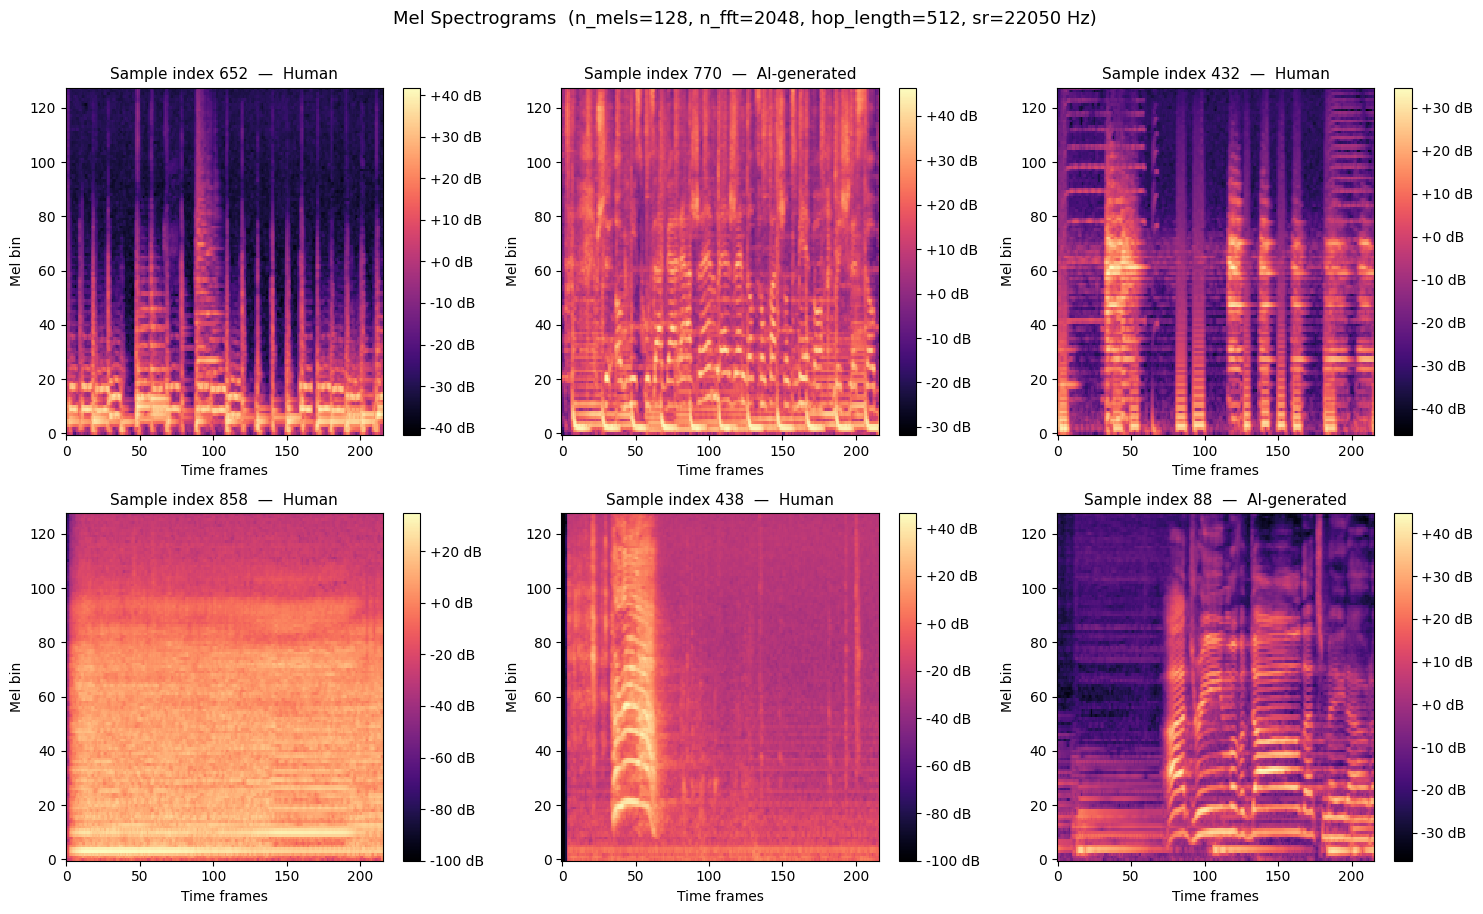

In [24]:
def visualize_mel_spectrograms(hf_dataset, n=6, seed=RANDOM_SEED):
    """Plot mel spectrograms for n random samples from hf_dataset, labelled by class."""
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(hf_dataset), size=n, replace=False).tolist()

    # Reuse MusicDataset loading logic by wrapping selected items in a plain list.
    # MusicDataset only calls __getitem__ and __len__ on hf_dataset, so a list works.
    items = [hf_dataset[i] for i in indices]
    tmp_dataset = MusicDataset(items)

    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
    axes = np.array(axes).flatten()

    for plot_idx in range(n):
        mel, label = tmp_dataset[plot_idx]   # (1, n_mels, time_frames), scalar
        mel_np = mel.squeeze(0).numpy()      # (n_mels, time_frames)

        ax = axes[plot_idx]
        img = ax.imshow(
            mel_np,
            aspect="auto",
            origin="lower",
            interpolation="nearest",
            cmap="magma"
        )
        label_str = "AI-generated" if int(label.item()) == 1 else "Human"
        ax.set_title(f"Sample index {indices[plot_idx]}  —  {label_str}", fontsize=11)
        ax.set_xlabel("Time frames")
        ax.set_ylabel("Mel bin")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")

    # Hide any unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle(
        f"Mel Spectrograms  (n_mels={N_MELS}, n_fft={FFT_SIZE}, hop_length={HOP_LENGTH}, sr={SAMPLE_RATE} Hz)",
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()


visualize_mel_spectrograms(ds, n=6)


## Split Dataset

The dataset is split into 70/15/15 for training, validation, and test sets. 

In [25]:
# 70/15/15 dataset split
train_test_split = ds.train_test_split( 
    test_size=0.30,  # 30% of the data will be used for validation and testing (15% each)
    seed=RANDOM_SEED,
    shuffle=True
)

val_test_split = train_test_split["test"].train_test_split(
    test_size=0.50, # split the 30% test set into 15% validation and 15% test
    seed=RANDOM_SEED,
    shuffle=True
)

train_dataset = MusicDataset(train_test_split["train"]) # create a MusicDataset instance for the training set
val_dataset = MusicDataset(val_test_split["train"]) 
test_dataset = MusicDataset(val_test_split["test"])

print(f"Train examples: {len(train_test_split['train'])}")
print(f"Validation examples: {len(val_test_split['train'])}")
print(f"Test examples: {len(val_test_split['test'])}")

Train examples: 700
Validation examples: 150
Test examples: 150


In [26]:
# data loaders
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": DATALOADER_NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}

if DATALOADER_NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = PERSISTENT_WORKERS
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader = DataLoader(
    train_dataset,
    shuffle=True,  # shuffle the training data for better generalization
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,  # no need to shuffle validation data
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,  # no need to shuffle test data
    **loader_kwargs,
)

## CNN Architecture

**Input** 
- Mel spectrogram with shape (1, 128, 216)
    - 1: grayscale image
    - 128: frequency axis (Mel bins)
    - 216: time frames (for 5 sec)

**Convolutional block 1:** Captures low-level audio features
- Conv2D
    - Input channels: 1
    - Output channels: 16
    - Kernel size: 3x3
    - Stride: 1
    - Padding: 1
- Batch Normalization
- ReLU activation
- MaxPooling 2x2
- Dropout: 0.2

Input:   (1, 128, 216)
Conv:    (16, 128, 216)
Pool:    (16, 64, 108)

**Convolutional block 2:** Mid-level musical patterns
Same as above, except
- Conv2D
    - Input channels: 16
    - Output channels: 32
- Dropout: 0.3

Input:   (16, 64, 108)
Conv:    (32, 64, 108)
Pool:    (32, 32, 54)

**Convolutional block 3:** High-level structural features
Same as above, except
- Conv2D
    - Input channels: 32
    - Output channels: 64
- Dropout: 0.4

Input:   (32, 32, 54)
Conv:    (64, 32, 54)
Pool:    (64, 16, 27)

**Fully connected block**
64 × 16 × 27 = 27,648 features
- Linear: 27,648 --> 256
- ReLU
- Dropout: 0.5
- Linear: 256 --> 1
- Sigmoid activation

**Output**
- output >= 0.5: AI-generated
- output < 0.5: human composed

**Loss and Optimization**
- Loss function: Binary Cross Entropy
- Optimizer: Adam


In [27]:
class MusicCNN(nn.Module):

    def __init__(self):

        super().__init__()

        # Block 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)

        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 16 * 27, 256)
        self.fc2 = nn.Linear(256, 1)


    def forward(self, x):

        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)

        x = self.dropout(F.relu(self.fc1(x)))

        # Return logits; sigmoid is applied only for metrics/thresholding.
        x = self.fc2(x)

        return x

In [28]:
# model setup
model = MusicCNN().to(DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

## Training Functions

In [29]:
# training loop
def train_epoch():

    model.train() # set the model to training mode (enables dropout and batch normalization updates)

    total_loss = 0 # cumulative loss for the epoch
    correct = 0 # count of correct predictions
    total = 0 # total number of samples processed

    for x, y in train_loader:

        x = x.to(DEVICE, non_blocking=PIN_MEMORY) # move input data to the same device as the model
        y = y.to(DEVICE, non_blocking=PIN_MEMORY).unsqueeze(1) # reshape labels to (batch_size, 1) for BCEWithLogitsLoss

        optimizer.zero_grad() # reset gradients before backpropagation

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            logits = model(x) # forward pass to get logits
            loss = criterion(logits, y) # compute the binary cross-entropy loss between logits and true labels

        scaler.scale(loss).backward() # backpropagation to compute gradients

        scaler.step(optimizer) # update model parameters based on computed gradients
        scaler.update()

        total_loss += loss.item() # accumulate loss for the epoch
        probs = torch.sigmoid(logits)
        predicted = (probs > 0.5).float() # convert predicted probabilities to binary labels using a threshold of 0.5
        correct += (predicted == y).sum().item() # count how many predictions match the true labels and accumulate the count of correct predictions
        total += y.size(0) # accumulate the total number of samples processed

    avg_loss = total_loss / len(train_loader) # calculate the average loss for the epoch
    accuracy = correct / total
    return avg_loss, accuracy

In [30]:
# validation loop
def evaluate(data_loader):

    model.eval() # set the model to evaluation mode (disables dropout and batch normalization updates)

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): # disable gradient computation for evaluation to save memory and computation

        for x, y in data_loader:

            x = x.to(DEVICE, non_blocking=PIN_MEMORY)
            y = y.to(DEVICE, non_blocking=PIN_MEMORY).unsqueeze(1)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
                logits = model(x)
                loss = criterion(logits, y)

            total_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).float()

            correct += (predicted == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return accuracy, avg_loss


def plot_metrics(train_losses, val_losses, train_errors, val_errors):
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_losses, label="Train Loss")
    ax1.plot(epochs, val_losses, label="Val Loss")
    ax1.set_title("Loss per Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    ax2.plot(epochs, train_errors, label="Train Error")
    ax2.plot(epochs, val_errors, label="Val Error")
    ax2.set_title("Error per Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Error Rate")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## Training Script

Epoch 1
  Train Loss: 2.5296 | Train Error: 0.3857
  Val Loss:   0.6801 | Val Accuracy: 0.7067
Epoch 2
  Train Loss: 0.5918 | Train Error: 0.2657
  Val Loss:   0.4574 | Val Accuracy: 0.8200
Epoch 3
  Train Loss: 0.5116 | Train Error: 0.2186
  Val Loss:   0.4213 | Val Accuracy: 0.8200
Epoch 4
  Train Loss: 0.4350 | Train Error: 0.1857
  Val Loss:   0.4600 | Val Accuracy: 0.8267
Epoch 5
  Train Loss: 0.3832 | Train Error: 0.1586
  Val Loss:   0.3968 | Val Accuracy: 0.8533
Epoch 6
  Train Loss: 0.3523 | Train Error: 0.1486
  Val Loss:   0.3577 | Val Accuracy: 0.8667
Epoch 7
  Train Loss: 0.3576 | Train Error: 0.1343
  Val Loss:   0.6041 | Val Accuracy: 0.7400
Epoch 8
  Train Loss: 0.2723 | Train Error: 0.1029
  Val Loss:   0.3103 | Val Accuracy: 0.9000
Epoch 9
  Train Loss: 0.2786 | Train Error: 0.0986
  Val Loss:   0.3689 | Val Accuracy: 0.8333
Epoch 10
  Train Loss: 0.2580 | Train Error: 0.1057
  Val Loss:   0.4673 | Val Accuracy: 0.8200
Epoch 11
  Train Loss: 0.2579 | Train Error: 0.09

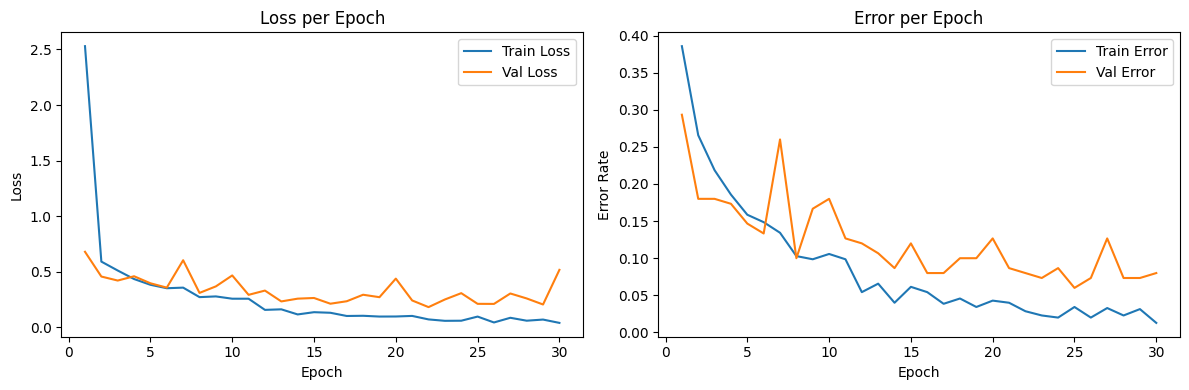

In [31]:
train_losses, val_losses = [], []
train_errors, val_errors = [], []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch() # train for one epoch and get the average training loss and accuracy
    val_acc, val_loss = evaluate(val_loader) # evaluate on the validation set to get accuracy and loss

    train_losses.append(train_loss) 
    val_losses.append(val_loss)
    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)

    print(f"Epoch {epoch+1}")   
    print(f"  Train Loss: {train_loss:.4f} | Train Error: {1 - train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

test_acc, test_loss = evaluate(test_loader)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

plot_metrics(train_losses, val_losses, train_errors, val_errors) # plot training and validation loss and error over epochs


In [32]:
# save model
torch.save(model.state_dict(), "models/musicCNN.pth")
